Study on "Noise Dressing of Financial Correlations Matrices" 

(Laurent Laloux,Pierre Cizeau, Jean-Philippe Bouchaud and Marc Potters)

1) Convert Dataset from https://datastackapi.com/dataset/spx-stock-data (2013-2018 S&P 500) into a matrix (we only keep stocks with full history)

In [2]:
import pandas as pd

df = pd.read_csv("all_stocks_5yr.csv")
df["date"] = pd.to_datetime(df["date"])   #to convert the string of numbers into an actual data

prices = df.pivot(   #we use the df.pivot to convert it into a matrix 
    index="date",
    columns="Name",
    values="close"   #we only keep the close price since there is no adjusted close in the dataset
)

prices = prices.dropna(axis=1)   #we drop all the stocks that does not have data for every day of the 5yr period

2) Build the empirical covariance matrix starting from the dataset

In [3]:
import numpy as np

log_prices = np.log(prices)
returns = log_prices.diff()
returns = returns.dropna()   #since the first line will now be NaN we remove it

returns_norm = (returns - returns.mean()) / returns.std(ddof=0)   #we normalize the returns (ddof=0 since we don't use the bessel correction)

C = (returns_norm.T @ returns_norm) / len(returns_norm)

3) Visualize the eigenvalues of the empirical covariance matrix (N=470, T=1258)

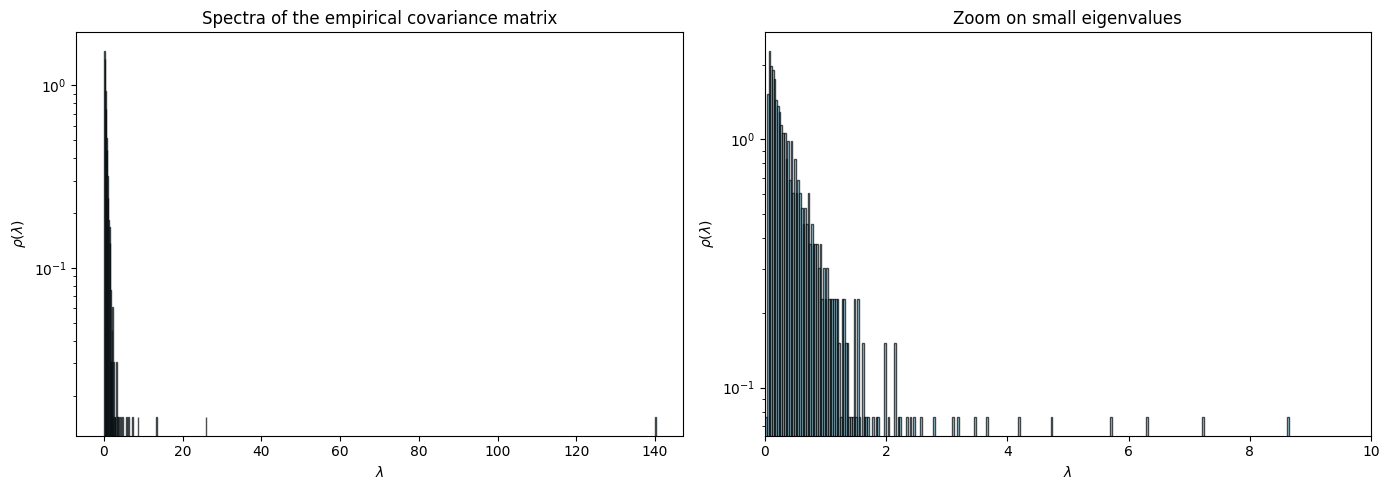

In [4]:
eigenvalues = np.linalg.eigvalsh(C)   #we use eigvalsh since the matrix is real and symmetric
eigenvalues = np.sort(eigenvalues)

import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14,5))  # 1 riga, 2 colonne

axes[0].hist(eigenvalues, bins=1000, density=True, alpha=0.7, color='skyblue', edgecolor='black')
axes[0].set_xlabel(r'$\lambda$')
axes[0].set_ylabel(r'$\rho(\lambda)$')
axes[0].set_title('Spectra of the empirical covariance matrix')
axes[0].set_yscale('log') 

axes[1].hist(eigenvalues, bins=5000, density=True, alpha=0.7, color='skyblue', edgecolor='black')
axes[1].set_xlim(0, 10)  
axes[1].set_xlabel(r'$\lambda$')
axes[1].set_ylabel(r'$\rho(\lambda)$')
axes[1].set_title('Zoom on small eigenvalues')
axes[1].set_yscale('log')  

plt.tight_layout()
plt.show()


4) Comparison with the spectrum of a Wishart Matrix that follows the Marcenko-Pastur law

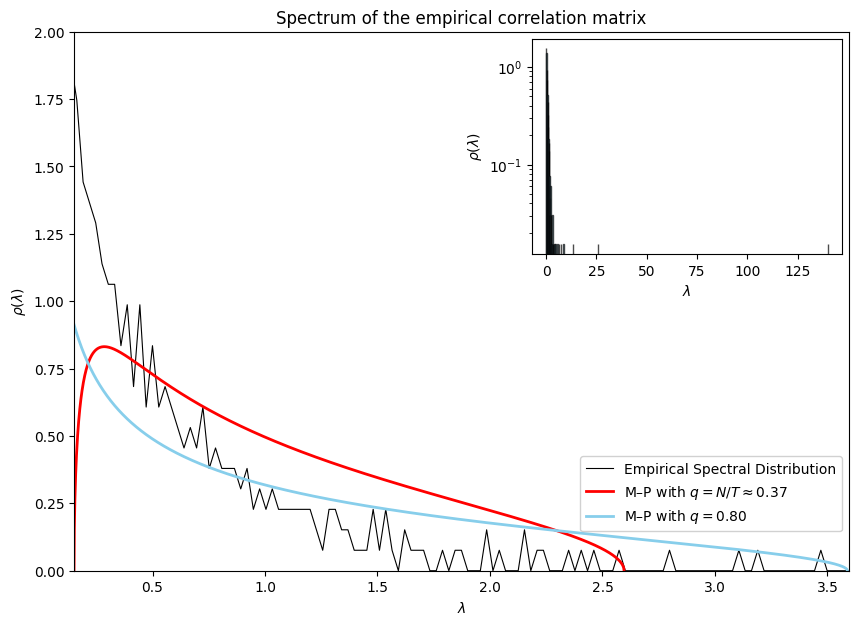

In [ ]:
N = returns_norm.shape[1]
T = returns_norm.shape[0]
q = N / T

lambda_minus = (1 - np.sqrt(q))**2
lambda_plus  = (1 + np.sqrt(q))**2
lambda_vals = np.linspace(lambda_minus, lambda_plus, 2000)
rho_mp = (np.sqrt(np.clip((lambda_plus - lambda_vals) * (lambda_vals - lambda_minus), 0, None)) / (2 * np.pi * q * lambda_vals)) #M-P law with q=N/T

q_user = 0.8
lambda_minus_user = (1 - np.sqrt(q_user))**2
lambda_plus_user  = (1 + np.sqrt(q_user))**2
lambda_vals_user = np.linspace(lambda_minus_user, lambda_plus_user, 2000)
rho_mp_user = (np.sqrt(np.clip((lambda_plus_user - lambda_vals_user) * (lambda_vals_user - lambda_minus_user),0,None,)) / (2 * np.pi * q_user * lambda_vals_user))  #M_P law with other q

fig, ax = plt.subplots(figsize=(10,7))

hist, bin_edges = np.histogram(eigenvalues, bins=5000, density=True)
bin_centers = 0.5 * (bin_edges[:-1] + bin_edges[1:])
ax.plot(bin_centers, hist, color='black', linewidth=0.8, label='Empirical Spectral Distribution')

ax.plot(lambda_vals, rho_mp, color='red', lw=2, label=rf'M–P with $q=N/T \approx {q:.2f}$')

ax.plot(lambda_vals_user,rho_mp_user,color='skyblue',lw=2,label=rf'M–P with $q = {q_user:.2f}$')

ax.set_xlabel(r'$\lambda$')
ax.set_ylabel(r'$\rho(\lambda)$')
ax.set_title('Spectrum of the empirical correlation matrix')
ax.set_xlim(lambda_minus, lambda_plus + 1)
ax.set_ylim(0,2)
ax.legend(loc='lower right',bbox_to_anchor=(1, 0.06), frameon=True, framealpha=0.9)

#Spettro completo
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
axins = inset_axes(ax, width="40%", height="40%", loc='upper right')
axins.hist(eigenvalues, bins=1000, density=True, alpha=0.7, color='skyblue', edgecolor='black')
axins.set_xlabel(r'$\lambda$')
axins.set_ylabel(r'$\rho(\lambda)$') 
axins.set_yscale('log')

plt.show()